<a href="https://colab.research.google.com/github/shafiqa-nabila/PCVK_Ganjil2026/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D. PRAKTIKUM FILTER
1. Buat fungsi konvolusi menggunakan algoritma yang telah dijelaskan pada Bagian C, tanpa
menggunakan library atau metode konvolusi dari OpenCV.
2. Berikut merupakan langkah-langkah yang dapat dilakukan:
a. Buat notebook baru pada google colab, dan beri nama Week7.ipynb. Simpan Salinan
pada akun github seperti pada modul sebelumnya.

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

c. Buatlah fungsi konvolusi. Catatan: parameter yang digunakan boleh dimodifikasi.
Misal, hanya menggunakan parameter image dan kernel saja, atau image, kernel, dan
padding.

In [32]:
def konvolusi(image, kernel):
    tinggi, lebar = image.shape
    k_tinggi, k_lebar = kernel.shape

    # Menentukan padding
    pad_y = k_tinggi // 2
    pad_x = k_lebar // 2

    # Menambahkan padding dengan nilai 0
    image_padded = np.pad(
        image,
        ((pad_y, pad_y), (pad_x, pad_x)),
        mode='constant'
    )

    # Menyiapkan hasil
    hasil = np.zeros_like(image, dtype=np.float32)

    # Proses konvolusi
    for i in range(tinggi):
        for j in range(lebar):

            # Mengambil area sesuai ukuran kernel
            area = image_padded[
                i:i + k_tinggi,
                j:j + k_lebar
            ]

            # Perkalian area dengan kernel lalu dijumlahkan
            hasil[i, j] = np.sum(area * kernel)

    # Membatasi nilai piksel 0-255
    hasil = np.clip(hasil, 0, 255)

    return hasil.astype(np.uint8)

d. Load citra yang akan diproses dan ubah menjadi citra keabuan

In [34]:
import cv2 as cv
import matplotlib.pyplot as plt

image_path = '/content/drive/MyDrive/PCVK 2026/Images/mandrill.tiff'

image = cv.imread(image_path)

gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

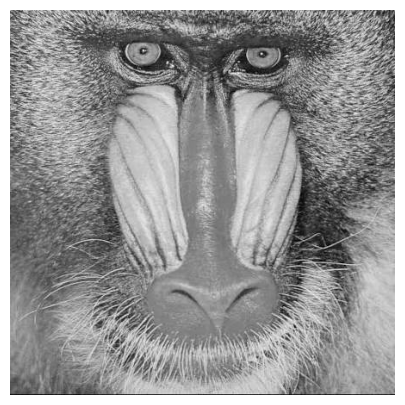

In [35]:
plt.figure(figsize=(8, 5))
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

e. Tentukan kernel yang akan digunakan, contohnya kernel untuk filter sharpening
sebagai berikut:

In [36]:
# Kernel Sharpening
kernel_sharpen = np.array([[ 0, -1,  0],
                          [-1,  5, -1],
                          [ 0, -1,  0]
], dtype=np.float32)

print("Kernel Sharpening:")
print(kernel_sharpen)

Kernel Sharpening:
[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]


f. Memanggil fungsi konvolusi yang telah dibuat sebelumnya, dan menampilkan hasil
konvolusinya:

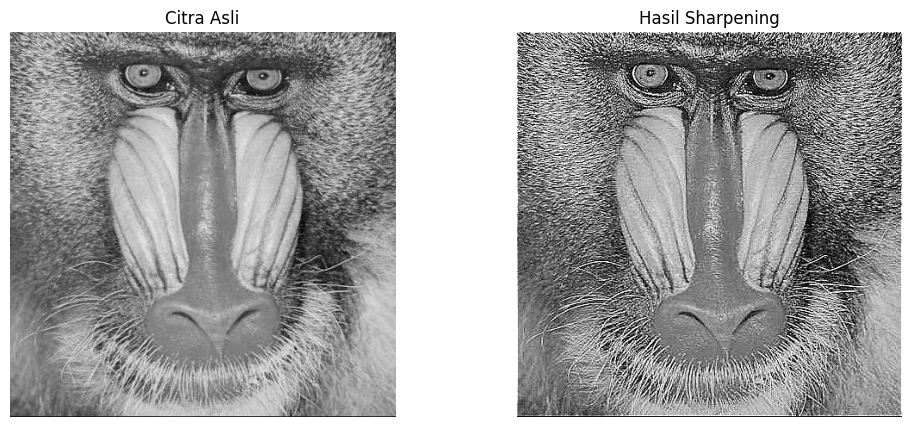

In [37]:
hasil_sharpen = konvolusi(gray, kernel_sharpen)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_sharpen, cmap='gray')
plt.title('Hasil Sharpening')
plt.axis('off')

plt.show()

3. Buat Image Filter untuk Average filter, low pass filter, high pass filter, dan beberapa filter
berikut:

**SHARPEN**

Kernel Sharpen:
[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]


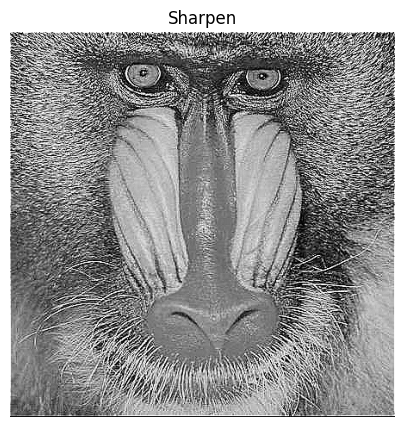

In [38]:
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)

hasil_sharpen = konvolusi(gray, kernel_sharpen)

print("Kernel Sharpen:")
print(kernel_sharpen)

plt.figure(figsize=(6, 5))
plt.imshow(hasil_sharpen, cmap='gray')
plt.title('Sharpen')
plt.axis('off')
plt.show()

**EMBOSS**

Kernel Emboss:
[[-2. -1.  0.]
 [-1.  1.  1.]
 [ 0.  1.  2.]]


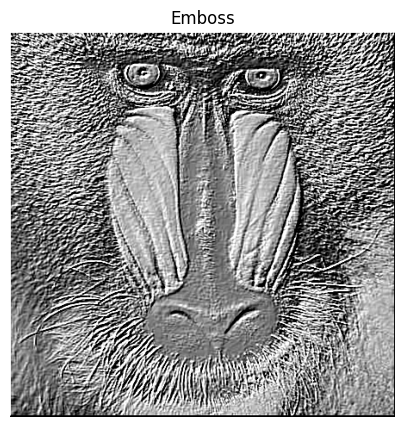

In [39]:
kernel_emboss = np.array([
    [-2, -1, 0],
    [-1,  1, 1],
    [ 0,  1, 2]
], dtype=np.float32)

hasil_emboss = konvolusi(gray, kernel_emboss)

print("Kernel Emboss:")
print(kernel_emboss)

plt.figure(figsize=(6, 5))
plt.imshow(hasil_emboss, cmap='gray')
plt.title('Emboss')
plt.axis('off')
plt.show()

**Left
Sobel
Edge
Detection**

Kernel Left Sobel:
[[ 1.  0. -1.]
 [ 2.  0. -2.]
 [ 1.  0. -1.]]


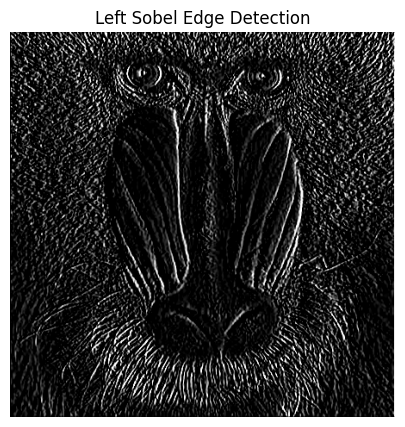

In [40]:
kernel_sobel = np.array([
    [1,  0, -1],
    [2,  0, -2],
    [1,  0, -1]
], dtype=np.float32)

hasil_sobel = konvolusi(gray, kernel_sobel)

print("Kernel Left Sobel:")
print(kernel_sobel)

plt.figure(figsize=(6, 5))
plt.imshow(hasil_sobel, cmap='gray')
plt.title('Left Sobel Edge Detection')
plt.axis('off')
plt.show()

**Canny
Edge
Detection**

Kernel Canny Edge Detection:
[[-1. -1. -1.]
 [-1.  8. -1.]
 [-1. -1. -1.]]


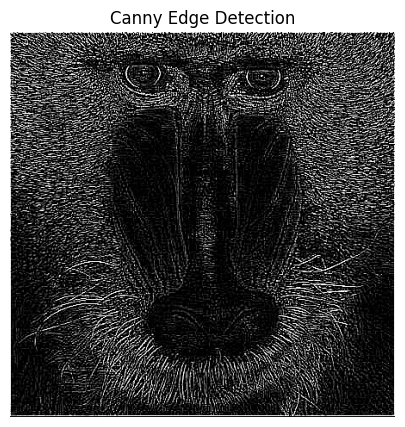

In [41]:
kernel_canny = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

hasil_canny = konvolusi(gray, kernel_canny)

print("Kernel Canny Edge Detection:")
print(kernel_canny)

plt.figure(figsize=(6, 5))
plt.imshow(hasil_canny, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')
plt.show()

**21x21
Gaussian
Blur**

Ukuran Kernel Gaussian: (21, 21)


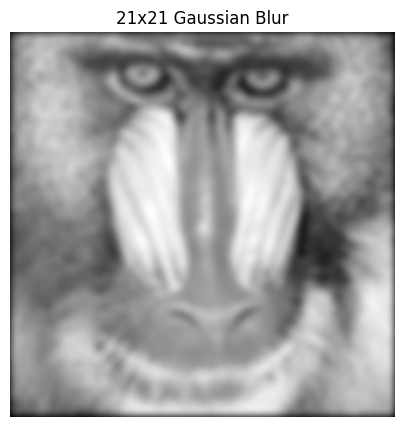

In [42]:
kernel_size = 21

sigma = math.sqrt(kernel_size)

gaussian_kernel_1d = cv.getGaussianKernel(
    kernel_size,
    sigma
)

gaussian_kernel = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()

hasil_gaussian = konvolusi(gray, gaussian_kernel)

print("Ukuran Kernel Gaussian:", gaussian_kernel.shape)

plt.figure(figsize=(6, 5))
plt.imshow(hasil_gaussian, cmap='gray')
plt.title('21x21 Gaussian Blur')
plt.axis('off')
plt.show()

E. FILTER LIBRARY DAN FILTER MODERN
Pada beberapa percobaan berikut ini kita akan melihat beberapa filter menggunakan library, filter
modern yang digunakan pada CNN, filter modern dengan kombinasi beberapa filter tradisional (tanpa
Deep Learning).

Percobaan 1:

Shape citra: (636, 636, 3)


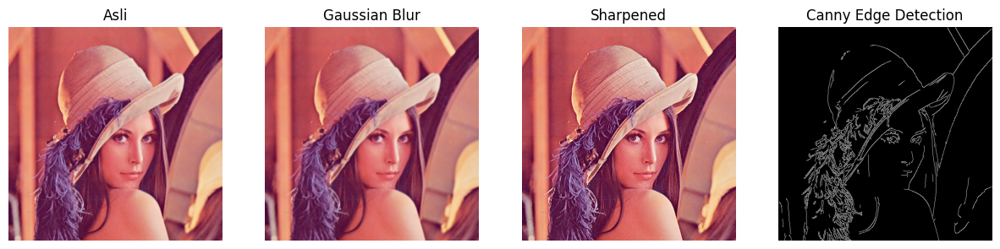

In [45]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


# ============================================================
# Fungsi tampil berdampingan
# ============================================================
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap='gray')
        else:  # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()


# ============================================================
# Load citra (pakai file yang ada di Drive Anda)
# ============================================================
img = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/Lenna.png')

# Kalau ingin pakai lena.jpg (kalau ada):
# img = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/lena.jpg')

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

print(f"Shape citra: {img.shape}")


# ============================================================
# 1. Gaussian Blur (pakai library)
# ============================================================
blur = cv.GaussianBlur(img, (7, 7), 1)

# ============================================================
# 2. Canny Edge Detection (pakai library)
# ============================================================
edges = cv.Canny(img_gray, 100, 200)

# ============================================================
# 3. Sharpen (pakai cv.filter2D + kernel)
# ============================================================
sharpen_kernel = np.array([[0, -1, 0],
                            [-1, 5, -1],
                            [0, -1, 0]], dtype=np.float32)

sharpened = cv.filter2D(img, -1, sharpen_kernel)

# ============================================================
# 4. Tampilkan berdampingan
# ============================================================
show_side_by_side(
    [img, blur, sharpened, edges],
    ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"]
)

Percobaan 2:


Shape citra: (636, 636, 3)


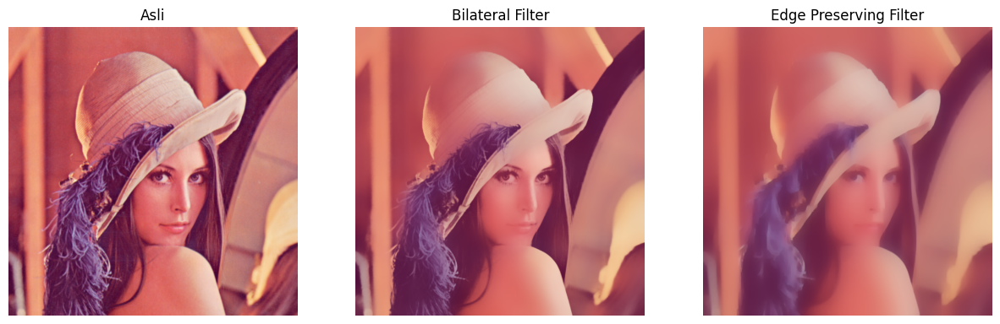

In [47]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


# ============================================================
# Fungsi tampil berdampingan
# ============================================================
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap='gray')
        else:  # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()


# ============================================================
# Load citra
# ============================================================
img = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/Lenna.png')

# Kalau ingin pakai lena.jpg:
# img = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/lena.jpg')

print(f"Shape citra: {img.shape}")


# ============================================================
# 1. Bilateral Filter (edge-preserving)
# ============================================================
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# ============================================================
# 2. Edge Preserving Filter (alternatif Guided Filter)
# ============================================================
edge_preserve = cv.edgePreservingFilter(img, flags=1,
                                        sigma_s=100, sigma_r=0.9)

# ============================================================
# 3. Tampilkan berdampingan
# ============================================================
show_side_by_side(
    [img, bilateral, edge_preserve],
    ["Asli", "Bilateral Filter", "Edge Preserving Filter"]
)

Percobaan 3:

Shape grayscale: (636, 636)
Shape fitur output: torch.Size([1, 4, 636, 636])


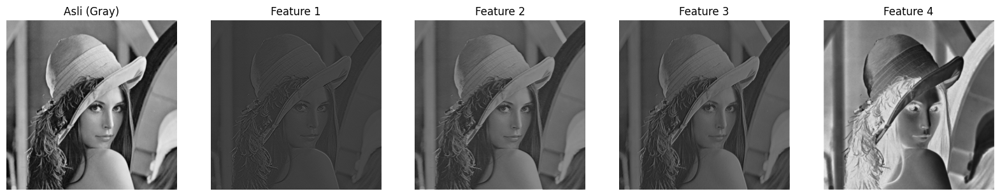

In [49]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


# ============================================================
# Fungsi tampil berdampingan
# ============================================================
def show_side_by_side(images, titles, figsize=(20, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap='gray')
        else:  # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()


# ============================================================
# Load citra
# ============================================================
img = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/Lenna.png')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

print(f"Shape grayscale: {img_gray.shape}")


# ============================================================
# Definisi model CNN sederhana
# ============================================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Conv2d: input=1 channel (grayscale), output=4 channel (4 feature map)
        # kernel 3x3, stride 1, padding 1
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)


model = SimpleCNN()

# ============================================================
# Ubah gambar ke tensor
# ============================================================
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# ============================================================
# Hasil CNN
# ============================================================
with torch.no_grad():
    features = model(img_tensor)

print(f"Shape fitur output: {features.shape}")
# Output: [1, 4, H, W] = [batch, channel, height, width]


# ============================================================
# Visualisasi feature maps
# ============================================================
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]

show_side_by_side(
    [img_gray] + feature_maps,
    ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))]
)

Percobaan 4:

Shape citra: (636, 636, 3)


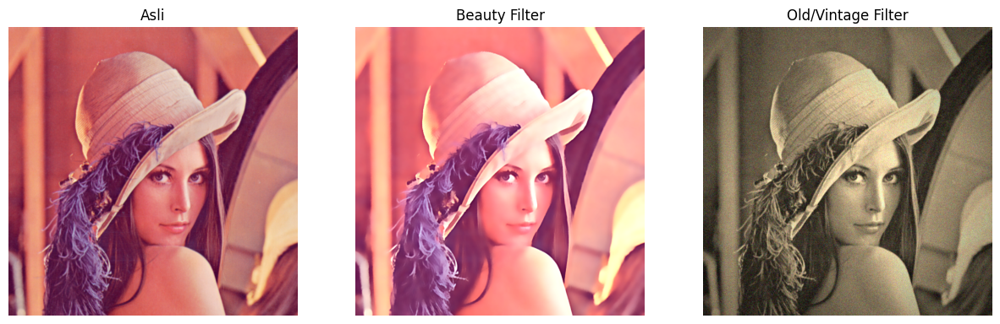

In [51]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


# ============================================================
# Fungsi tampil berdampingan
# ============================================================
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap='gray')
        else:  # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()


# ============================================================
# Load citra
# ============================================================
img = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/Lenna.png')
print(f"Shape citra: {img.shape}")


# ============================================================
# 1. BEAUTY FILTER
# ============================================================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2   # contrast
beta = 15     # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)


# ============================================================
# 2. OLD / VINTAGE FILTER
# ============================================================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                          [0.349, 0.686, 0.168],
                          [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()

vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)


# ============================================================
# Tampilkan hasil
# ============================================================
show_side_by_side(
    [img, beauty, old_img],
    ["Asli", "Beauty Filter", "Old/Vintage Filter"],
    figsize=(15, 5)
)

Percobaan 5:

Shape citra: (636, 636, 3)


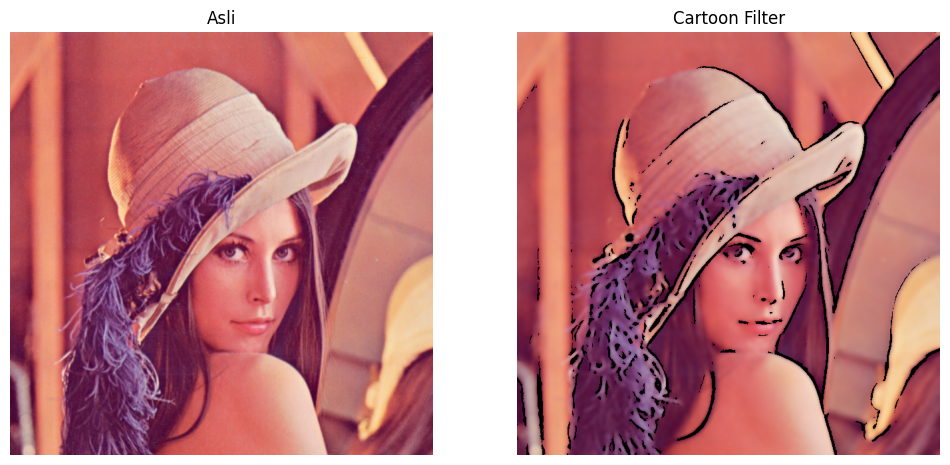

In [53]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


# ============================================================
# Fungsi tampil berdampingan
# ============================================================
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap='gray')
        else:  # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()


# ============================================================
# Load citra
# ============================================================
img = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/Lenna.png')
print(f"Shape citra: {img.shape}")


# ============================================================
# Anime / Cartoon Filter
# ============================================================
# Step 1: Edge detection (pakai median blur dulu agar gambar
#         menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                              cv.ADAPTIVE_THRESH_MEAN_C,
                              cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side(
    [img, cartoon],
    ["Asli", "Cartoon Filter"],
    figsize=(12, 6)
)

Percobaan 6:

Shape citra: (720, 1080, 3)


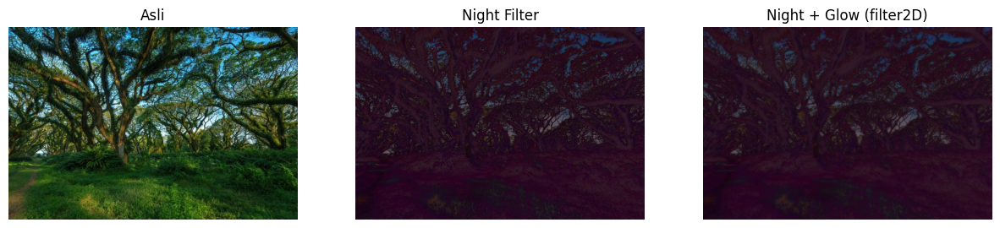

In [54]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


# ============================================================
# Fungsi tampil berdampingan
# ============================================================
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap='gray')
        else:  # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()


# ============================================================
# Load citra
# ============================================================
img = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/djawatan.png')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
print(f"Shape citra: {img.shape}")


# ============================================================
# Night Filter
# ============================================================
# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasi asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

# Tampilkan
show_side_by_side(
    [img, night, night_glow],
    ["Asli", "Night Filter", "Night + Glow (filter2D)"],
    figsize=(15, 5)
)

Percobaan 7:

Shape citra: (720, 1080, 3)


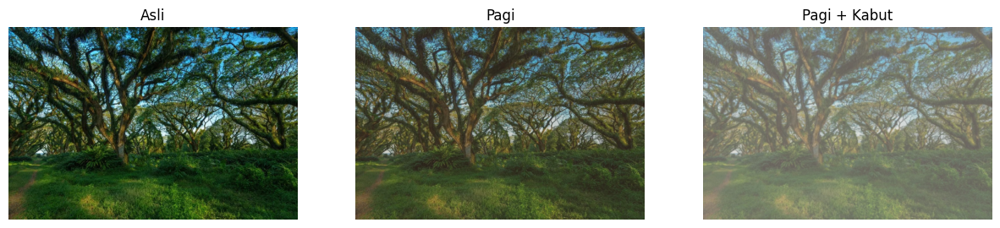

In [56]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


# ============================================================
# Fungsi tampil berdampingan
# ============================================================
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap='gray')
        else:  # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()


# ============================================================
# Load citra
# ============================================================
img = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/djawatan.png')
print(f"Shape citra: {img.shape}")


# ============================================================
# Filter Suasana Pagi dan Kabut
# ============================================================
# Step 1: Kurangi kontras & cerahkan
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone (kemerahan / orange)
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# Kernel blur Gaussian-Like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T   # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# Tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

# Tampilkan
show_side_by_side(
    [img, pagi, kabut],
    ["Asli", "Pagi", "Pagi + Kabut"],
    figsize=(15, 5)
)

Tugas Praktikum
1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and
Pepper”

a. Tambahkan noise bintik hitam-putih (Salt and Pepper) ke sebuah citra keabuan (grayscale).

b. Terapkan Mean Filter(3 x 3) dan Median Filter (3 x 3).
Pengolahan Citra dan Visi Komputer – Jurusan Teknologi Informasi

c. Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus
noise tersebut dibanding Mean Filter.

Shape citra: (447, 447)


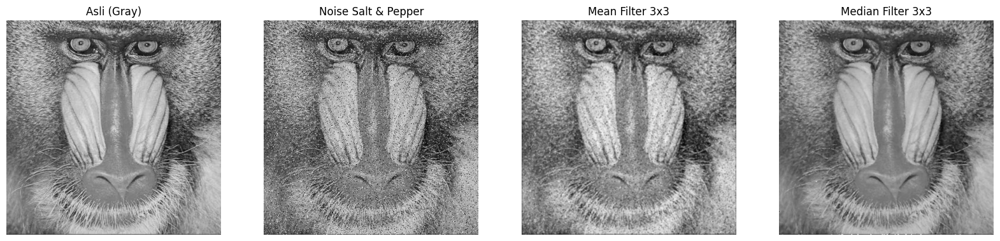

PSNR terhadap citra asli (makin tinggi makin baik)
PSNR Noise          : 15.82 dB
PSNR Mean Filter    : 21.50 dB
PSNR Median Filter  : 24.15 dB


In [57]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


def show_side_by_side(images, titles, figsize=(18, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis("off")
    plt.show()


# Load citra
img = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
print(f"Shape citra: {img_gray.shape}")


# ---------- 1a. Tambah noise Salt & Pepper ----------
def add_salt_pepper(image, salt_prob=0.05, pepper_prob=0.05):
    noisy = np.copy(image)
    total = image.size

    # Salt (putih = 255)
    num_salt = int(total * salt_prob)
    coords = [np.random.randint(0, i, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255

    # Pepper (hitam = 0)
    num_pepper = int(total * pepper_prob)
    coords = [np.random.randint(0, i, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0

    return noisy


np.random.seed(42)  # agar hasil konsisten
noisy_img = add_salt_pepper(img_gray, salt_prob=0.05, pepper_prob=0.05)


# ---------- 1b. Mean Filter 3x3 & Median Filter 3x3 ----------
# Mean Filter manual
def mean_filter(image, ksize=3):
    kernel = np.ones((ksize, ksize), dtype=np.float32) / (ksize * ksize)
    img_h, img_w = image.shape
    pad = ksize // 2
    padded = np.pad(image, pad, mode='constant')
    output = np.zeros_like(image, dtype=np.float32)

    for y in range(img_h):
        for x in range(img_w):
            region = padded[y:y+ksize, x:x+ksize]
            output[y, x] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)


mean_result = mean_filter(noisy_img, ksize=3)
median_result = cv.medianBlur(noisy_img, 3)   # atau manual np.median


# ---------- 1c. Tampilkan & analisis ----------
show_side_by_side(
    [img_gray, noisy_img, mean_result, median_result],
    ["Asli (Gray)", "Noise Salt & Pepper", "Mean Filter 3x3", "Median Filter 3x3"],
    figsize=(20, 5)
)


# PSNR sebagai ukuran kuantitatif
def psnr(original, filtered):
    mse = np.mean((original.astype(np.float64) - filtered.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

print("=" * 60)
print("PSNR terhadap citra asli (makin tinggi makin baik)")
print("=" * 60)
print(f"PSNR Noise          : {psnr(img_gray, noisy_img):.2f} dB")
print(f"PSNR Mean Filter    : {psnr(img_gray, mean_result):.2f} dB")
print(f"PSNR Median Filter  : {psnr(img_gray, median_result):.2f} dB")
print("=" * 60)

2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)

a. Buat kernel penajaman (Sharpening Kernel) ukuran 3 x 3 dan 5 x 5.

b. Terapkan pada citra yang sedikit buram (blurry).

c. Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang
dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.

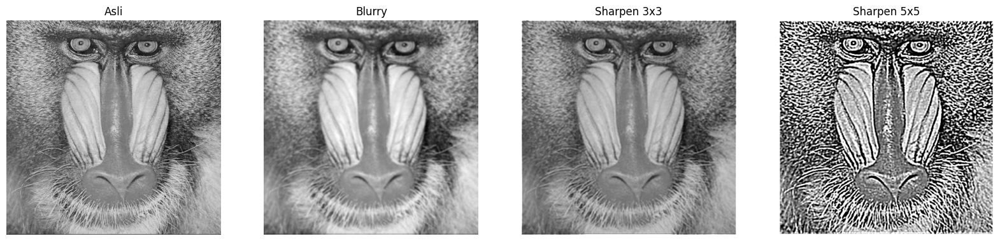

Metode               Ketajaman (Laplacian)     Noise (Std)    
----------------------------------------------------------------------
Asli                 3416.37                   15.72          
Blurry               42.91                     2.75           
Sharpen 3x3          749.93                    8.66           
Sharpen 5x5          12377.66                  35.66          


In [58]:
# Load citra
img = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Buat citra sedikit buram sebagai input
blurry = cv.GaussianBlur(img_gray, (5, 5), 1.5)


# ---------- 2a. Kernel Sharpening 3x3 dan 5x5 ----------
kernel_3x3 = np.array([[ 0, -1,  0],
                        [-1,  5, -1],
                        [ 0, -1,  0]], dtype=np.float32)

kernel_5x5 = np.array([[-1, -1, -1, -1, -1],
                        [-1, -1, -1, -1, -1],
                        [-1, -1, 25, -1, -1],
                        [-1, -1, -1, -1, -1],
                        [-1, -1, -1, -1, -1]], dtype=np.float32)


# ---------- 2b. Terapkan pada citra blurry ----------
def apply_filter(image, kernel):
    pad = kernel.shape[0] // 2
    padded = np.pad(image, pad, mode='constant')
    h, w = image.shape
    k_h, k_w = kernel.shape
    output = np.zeros_like(image, dtype=np.float32)

    for y in range(h):
        for x in range(w):
            region = padded[y:y+k_h, x:x+k_w]
            output[y, x] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)


sharp_3x3 = apply_filter(blurry, kernel_3x3)
sharp_5x5 = apply_filter(blurry, kernel_5x5)


# ---------- 2c. Tampilkan & evaluasi ----------
show_side_by_side(
    [img_gray, blurry, sharp_3x3, sharp_5x5],
    ["Asli", "Blurry", "Sharpen 3x3", "Sharpen 5x5"],
    figsize=(20, 5)
)


# Metrik: ketajaman (Laplacian variance) & noise estimation
def ketajaman(img):
    return cv.Laplacian(img, cv.CV_64F).var()

def noise_level(img):
    blur = cv.GaussianBlur(img, (5, 5), 0)
    return np.std(img.astype(np.float64) - blur.astype(np.float64))

print("=" * 70)
print(f"{'Metode':<20} {'Ketajaman (Laplacian)':<25} {'Noise (Std)':<15}")
print("-" * 70)
for nama, im in [("Asli", img_gray), ("Blurry", blurry),
                 ("Sharpen 3x3", sharp_3x3), ("Sharpen 5x5", sharp_5x5)]:
    print(f"{nama:<20} {ketajaman(im):<25.2f} {noise_level(im):<15.2f}")
print("=" * 70)

3. Tugas Kreasi: Filter Kartun Sederhana

a. Buatlah sebuah fungsi kustom bernama kartun(image) yang menggabungkan:
* Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata.
* Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.
* Penggabungan (kombinasi) keduanya menggunakan operasi logika/perkalian piksel.

b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan.

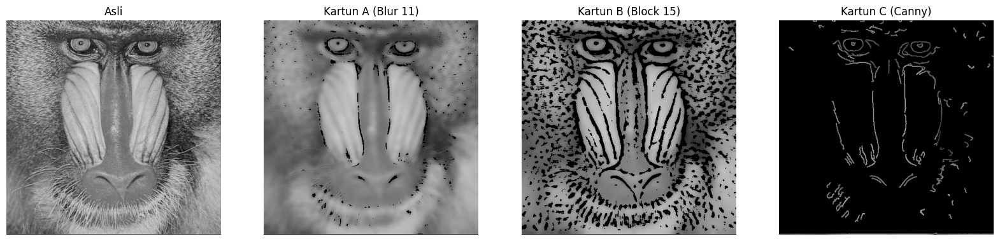

In [61]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

def show_side_by_side(images, titles, figsize=(20, 6)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()


def kartun_A(image):
    color = cv.bilateralFilter(image, d=15, sigmaColor=250, sigmaSpace=250)
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 11)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                  cv.ADAPTIVE_THRESH_MEAN_C,
                                  cv.THRESH_BINARY, 9, 9)
    edges_3ch = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)
    return cv.bitwise_and(color, edges_3ch)


def kartun_B(image):
    color = cv.bilateralFilter(image, d=15, sigmaColor=250, sigmaSpace=250)
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                  cv.ADAPTIVE_THRESH_MEAN_C,
                                  cv.THRESH_BINARY, 15, 5)
    edges_3ch = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)
    return cv.bitwise_and(color, edges_3ch)


def kartun_C(image):
    color = cv.bilateralFilter(image, d=15, sigmaColor=250, sigmaSpace=250)
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.Canny(gray_blur, 100, 200)
    kernel = np.ones((2, 2), np.uint8)
    edges = cv.dilate(edges, kernel, iterations=1)
    edges_3ch = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)
    return cv.bitwise_and(color, edges_3ch)


# Load citra
img = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/mandrill.tiff')

# Terapkan ketiga opsi
hasil_A = kartun_A(img)
hasil_B = kartun_B(img)
hasil_C = kartun_C(img)

# Tampilkan semua
show_side_by_side(
    [img, hasil_A, hasil_B, hasil_C],
    ["Asli", "Kartun A (Blur 11)", "Kartun B (Block 15)", "Kartun C (Canny)"]
)